# Imports

Enable operations to use the cpu if no Apple gpu implementation is available

In [1]:
%env PYTORCH_ENABLE_MPS_FALLBACK=1

env: PYTORCH_ENABLE_MPS_FALLBACK=1


Reload modules automagically if they change

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import os
import pickle
import json
import sklearn
import ot
import torch
from ot_utils import *
from sklearn.svm import SVC
from Utils.SVM_utils import test_svm, train_svm
from einops import rearrange
from Utils.visualization_utils import visualize_barycenter_diracs, plot_images, plot_pca_for_arrays
from Utils.joint_OT_mapping_linear_classreg import free_support_sinkhorn_barycenter, compute_joint_OT_mapping
from warnings import catch_warnings
from map_hyperparam import optimize_hyperparams
from sklearn.cluster import MiniBatchKMeans

In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
device

device(type='mps')

# Data

In [5]:
data_path = '/Users/balazsmorvay/PycharmProjects/fmri_classifier/Data/Office-Caltech'

Read the image features

In [6]:
dataset = np.load(os.path.join(data_path, 'Objects_Decaf.npy'))
with open(os.path.join(data_path, 'Objects_crossval_index.json'), 'r') as f:
    fold_dict = json.loads(f.read())

domain_names = ['Webcam', 'Amazon', 'dslr', 'Caltech']

Set the number of classes within each domain

In [7]:
n_classes = 10
standardize = False

In [8]:
dataset.shape

(2533, 4098)

In [9]:
X = dataset[:, :-2]
#if standardize:
#    X = (X - np.mean(X, axis=0)) / np.std(X, axis=0)
#else:
#    # Feature scaling
#    X = (X - np.min(X, axis=0)) / (np.max(X, axis=0) - np.min(X, axis=0))

y = np.array(dataset[:, -2], dtype=int)
m = np.array(dataset[:, -1], dtype=int)
domains = np.unique(m).astype(int)
targets = domains
n_domains = len(domains)

Dataset has shape n_points x n_features

In [10]:
X.shape, y.shape, targets.shape

((2533, 4096), (2533,), (4,))

### Number of samples coming from a given domain, having a given class

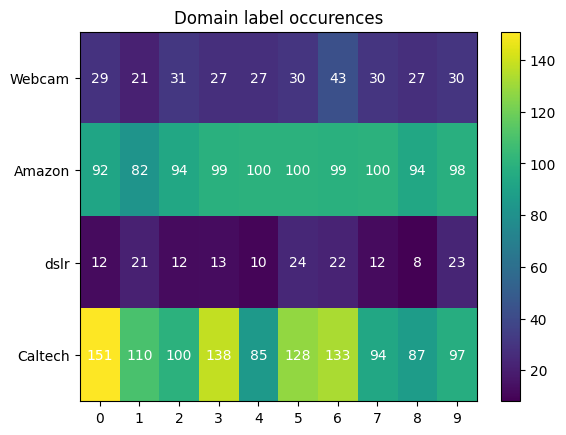

In [11]:
label_domain_occurence = np.zeros((4, 10), dtype=int)
for label in range(10):
    for i, domain in enumerate(domains):
        domain_indices = np.where(m == domain)
        domain_labels = y[domain_indices]
        label_indices = np.where(domain_labels == label+1)
        label_domain_occurence[i][label] = len(label_indices[0])

fig, ax = plt.subplots()
cax = ax.imshow(label_domain_occurence, cmap='viridis', aspect='auto')
for (i, j), val in np.ndenumerate(label_domain_occurence):
    ax.text(j, i, f'{val}', ha='center', va='center', color='white')
fig.colorbar(cax)
ax.set_xticks(np.arange(10))
ax.set_yticks(np.arange(4))
ax.set_xticklabels(str(i) for i in range(10))
ax.set_yticklabels(domain_names)
plt.title('Domain label occurences')
plt.show()

# Training

In [12]:
X_all = []
y_all = []
for i, domain in enumerate(domains):
    domain_indices = np.where(m == domain)
    X_all.append(torch.tensor(X[domain_indices], dtype=torch.float32, device=device))
    y_all.append(torch.tensor(y[domain_indices], dtype=torch.int, device=device))

In [13]:
X_trains = []
X_tests = []
y_trains = []
y_tests = []

for i in range(len(X_all)):
    X_i = X_all[i].cpu()
    y_i = y_all[i].cpu()
    X_i_train, X_i_test, y_i_train, y_i_test = sklearn.model_selection.train_test_split(X_i, y_i, train_size=0.3, shuffle=True, stratify=y_i, random_state=42)
    X_trains.append(X_i_train.to(device))
    X_tests.append(X_i_test.to(device))
    y_trains.append(y_i_train.to(device))
    y_tests.append(y_i_test.to(device))

In [14]:
X_trains[0].mean()

tensor(1.4348, device='mps:0')

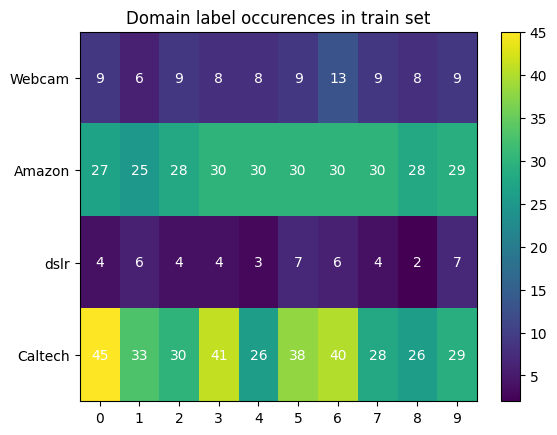

In [15]:
label_domain_occurence = np.zeros((4, 10), dtype=int)
for label in range(10):
    for i in range(n_domains):
        domain_labels = y_trains[i]
        label_indices = np.where(domain_labels.cpu() == label+1)
        label_domain_occurence[i][label] = len(label_indices[0])

fig, ax = plt.subplots()
cax = ax.imshow(label_domain_occurence, cmap='viridis', aspect='auto')
for (i, j), val in np.ndenumerate(label_domain_occurence):
    ax.text(j, i, f'{val}', ha='center', va='center', color='white')
fig.colorbar(cax)
ax.set_xticks(np.arange(10))
ax.set_yticks(np.arange(4))
ax.set_xticklabels(str(i) for i in range(10))
ax.set_yticklabels(domain_names)
plt.title('Domain label occurences in train set')
plt.show()

Concatenate the train samples into one tensor

In [16]:
Xs = torch.concatenate(tensors=X_trains, dim=0)
ys = torch.concatenate(y_trains, dim=0)
Xs.shape, ys.shape

(torch.Size([758, 4096]), torch.Size([758]))

In [17]:
n_features = 4096

In [18]:
model = train_svm(X_trains[0].cpu(), y_trains[0].cpu(), kernel='rbf', C=1.0)
model.fit_status_ == 0

[LibSVM].*.*
optimization finished, #iter = 31
obj = -3.714448, rho = 0.214794
nSV = 15, nBSV = 0
.*.*
optimization finished, #iter = 42
obj = -4.692344, rho = 0.279217
nSV = 18, nBSV = 0
.*
optimization finished, #iter = 31
obj = -5.626428, rho = 0.387746
nSV = 17, nBSV = 2
.*.*
optimization finished, #iter = 34
obj = -3.610927, rho = 0.389529
nSV = 17, nBSV = 0
.*.*
optimization finished, #iter = 39
obj = -4.749156, rho = 0.406507
nSV = 18, nBSV = 0
.*
optimization finished, #iter = 39
obj = -6.314869, rho = 0.346856
nSV = 22, nBSV = 4
.*
optimization finished, #iter = 31
obj = -5.859736, rho = 0.304120
nSV = 18, nBSV = 3
.*
optimization finished, #iter = 30
obj = -3.838141, rho = 0.243667
nSV = 17, nBSV = 0
.*
optimization finished, #iter = 29
obj = -6.260178, rho = 0.361745
nSV = 18, nBSV = 4
.*
optimization finished, #iter = 29
obj = -3.908842, rho = 0.022335
nSV = 15, nBSV = 0
.*.*
optimization finished, #iter = 28
obj = -4.357911, rho = 0.075192
nSV = 14, nBSV = 0
.*
optimizatio

True

{'accuracy': 0.6676602086438153, 'recall': array([0.56923077, 0.9122807 , 0.72727273, 0.62318841, 0.71428571,
       0.48571429, 0.91304348, 0.78571429, 0.03030303, 0.92753623]), 'precision': array([0.94871795, 1.        , 0.75      , 0.78181818, 0.75757576,
       0.80952381, 0.35      , 0.96491228, 1.        , 0.56140351]), 'fscore': array([0.71153846, 0.95412844, 0.73846154, 0.69354839, 0.73529412,
       0.60714286, 0.5060241 , 0.86614173, 0.05882353, 0.69945355])}


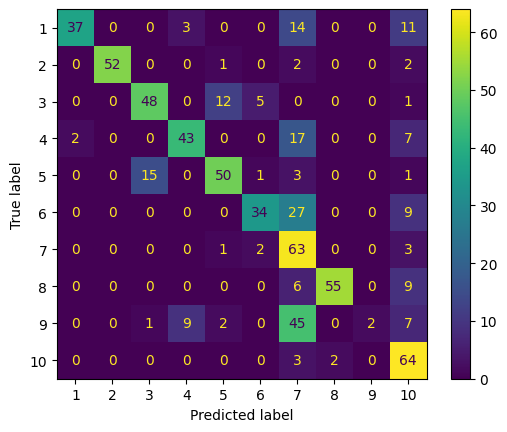

In [19]:
metrics, disp = test_svm(model, X_tests[1].cpu(), y_tests[1].cpu())
disp.plot()
print(metrics)

In [20]:
xs = X_trains[1]
xt = X_trains[0]
ys = y_trains[1]
yt = y_trains[0]
M = dist_classreg(xs, xt, ys, yt, device=device)

a = torch.tensor([1.0 / xs.shape[0]] * xs.shape[0], dtype=torch.float32, device=device)
b = torch.tensor([1.0 / xt.shape[0]] * xt.shape[0], dtype=torch.float32, device=device)

P = ot.sinkhorn(a=a, b=b, reg=2e-1, M=M, method='sinkhorn_log')

/Users/balazsmorvay/anaconda3/envs/fmri_classifier/lib/python3.11/site-packages/ot/bregman/_sinkhorn.py:748: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn("Sinkhorn did not converge. You might want to "


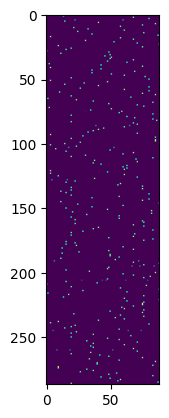

In [21]:
plt.imshow(P.cpu())

In [22]:
transp_xs = barycentric_mapping(xs, xt, X_tests[1], P)

{'accuracy': 0.8852459016393442, 'recall': array([0.89230769, 0.9122807 , 0.77272727, 0.79710145, 0.94285714,
       0.94285714, 0.86956522, 0.88571429, 0.87878788, 0.95652174]), 'precision': array([1.        , 1.        , 1.        , 0.94827586, 0.75862069,
       0.90410959, 0.95238095, 0.86111111, 0.90625   , 0.70967742]), 'fscore': array([0.94308943, 0.95412844, 0.87179487, 0.86614173, 0.84076433,
       0.92307692, 0.90909091, 0.87323944, 0.89230769, 0.81481481])}


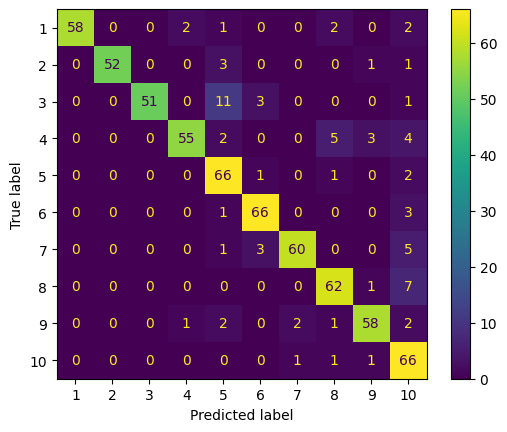

In [23]:
metrics, disp = test_svm(model, transp_xs.cpu(), y_tests[1].cpu())
disp.plot()
print(metrics)

# Using barycenter distributions

Lets first compute the barycenter of the distribution

In [24]:
n_train = 0
for i in range(len(X_trains)):
    n_train += X_trains[i].shape[0]
n_train

758

In [25]:
a1, a2, a3, a4 = ot.unif(len(X_trains[0])), ot.unif(len(X_trains[1])), ot.unif(len(X_trains[2])), ot.unif(len(X_trains[3]))
weights = [torch.tensor(a1, dtype=torch.float32, device=device), torch.tensor(a2, dtype=torch.float32, device=device), torch.tensor(a3, dtype=torch.float32, device=device), torch.tensor(a4, dtype=torch.float32, device=device)]

In [26]:
reg = 1e-1  # Entropic Regularization
numItermax = 10  # Maximum number of iterations for the Barycenter algorithm
numInnerItermax = 3000  # Maximum number of sinkhorn iterations

recompute = True

if not recompute and os.path.exists('barycenter_simple.npy'):
    barycenter = np.load('barycenter_simple.npy')
    barycenter = torch.tensor(barycenter, dtype=torch.float32, device=device)
    print('Barycenter loaded')
else:
    barycenter = free_support_sinkhorn_barycenter(
        measures_locations=X_trains,
        measures_weights=weights,
        reg=reg,
        numItermax=numItermax,
        numInnerItermax=numInnerItermax,
        verbose=True,
        X_init=torch.rand(size=(n_train, n_features), device=device),
        b=torch.ones(size=(n_train,), device=device) / n_train,
        method='sinkhorn_log',
        stopThr=0.0001
    )
    np.save('barycenter_simple.npy', barycenter.cpu())

/Users/balazsmorvay/anaconda3/envs/fmri_classifier/lib/python3.11/site-packages/ot/bregman/_sinkhorn.py:748: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn("Sinkhorn did not converge. You might want to "


iteration %d, displacement_square_norm=%f
 0 tensor(25869992., device='mps:0')
iteration %d, displacement_square_norm=%f
 1 tensor(3874861.7500, device='mps:0')
iteration %d, displacement_square_norm=%f
 2 tensor(884091.7500, device='mps:0')
iteration %d, displacement_square_norm=%f
 3 tensor(204019.0625, device='mps:0')
iteration %d, displacement_square_norm=%f
 4 tensor(46581.6445, device='mps:0')
iteration %d, displacement_square_norm=%f
 5 tensor(2.8622, device='mps:0')
iteration %d, displacement_square_norm=%f
 6 tensor(0.8519, device='mps:0')
iteration %d, displacement_square_norm=%f
 7 tensor(0.8519, device='mps:0')
iteration %d, displacement_square_norm=%f
 8 tensor(0.8519, device='mps:0')
iteration %d, displacement_square_norm=%f
 9 tensor(0.8519, device='mps:0')


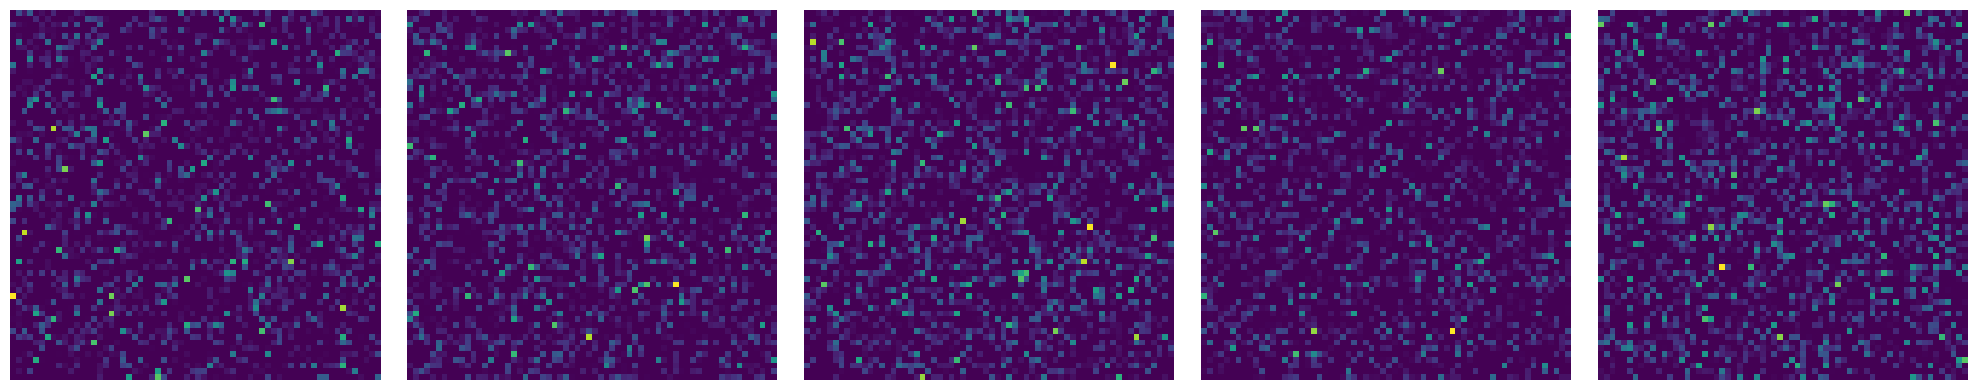

In [27]:
visualize_barycenter_diracs(barycenter.cpu(), num_images=5, random_seed=42)
plt.show()

In [28]:
barycenter.shape

torch.Size([758, 4096])

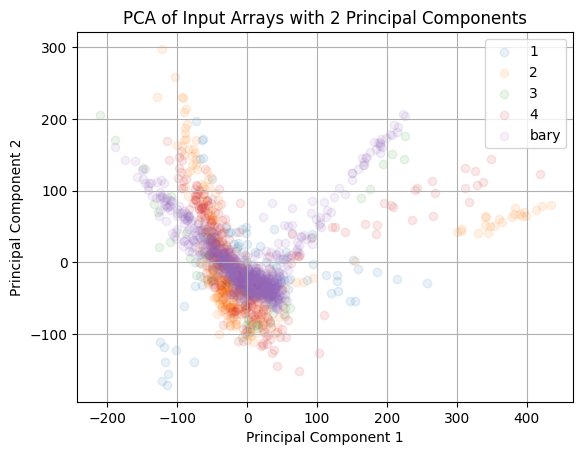

In [29]:
plot_pca_for_arrays(arrays=[X_trains[0].cpu(), X_trains[1].cpu(), X_trains[2].cpu(), X_trains[3].cpu(), barycenter.cpu()], n_components=2, labels=['1', '2', '3', '4', 'bary'])
plt.show()

In [30]:
y_bari = torch.concatenate(y_trains).cpu()
y_bari.shape

torch.Size([758])

In [31]:
X_trains[0].shape

torch.Size([88, 4096])

In [33]:
# Source 1 to bary
xs = torch.tensor([1.0 / xs.shape[0]] * xs.shape[0], dtype=torch.float32, device=device)
b = torch.tensor([1.0 / xt.shape[0]] * xt.shape[0], dtype=torch.float32, device=device)
G, L, loss = compute_joint_OT_mapping(xs=X_trains[0],
                                      xt=barycenter,
                                      ys=y_trains[0].cpu(),
                                      yt=y_bari.cpu(),
                                      method='gaussian',
                                      mu=1e-3,
                                      eta=1e-2,
                                      numItermax=30,
                                      numInnerItermax=int(1e8),
                                      stopThr=1e-8,
                                      stopInnerThr=1e-8,
                                      bias=False,
                                      class_reg=True)

G.shape, L.shape

It.  |Loss        |Delta loss
--------------------------------
    0|2.777754e+04|0.000000e+00
    1|2.764664e+04|-4.712244e-03
    2|2.751757e+04|-4.668712e-03
    3|2.739236e+04|-4.550360e-03
    4|2.726963e+04|-4.480179e-03
    5|2.714982e+04|-4.393624e-03
    6|2.703248e+04|-4.322010e-03
    7|2.691749e+04|-4.253780e-03
    8|2.680452e+04|-4.196999e-03
    9|2.669444e+04|-4.106701e-03
   10|2.658666e+04|-4.037300e-03
   11|2.648098e+04|-3.974914e-03
   12|2.637738e+04|-3.912300e-03
   13|2.627595e+04|-3.845402e-03
   14|2.617650e+04|-3.785023e-03
   15|2.607902e+04|-3.723671e-03
   16|2.598369e+04|-3.655656e-03
   17|2.589015e+04|-3.599915e-03
   18|2.579826e+04|-3.549100e-03
   19|2.570823e+04|-3.489894e-03
It.  |Loss        |Delta loss
--------------------------------
   20|2.562023e+04|-3.422952e-03
   21|2.553381e+04|-3.372960e-03
   22|2.544919e+04|-3.314309e-03
   23|2.536626e+04|-3.258715e-03
   24|2.528495e+04|-3.205153e-03
   25|2.520528e+04|-3.150883e-03
   26|2.512727e+0

(torch.Size([88, 758]), torch.Size([88, 4096]))

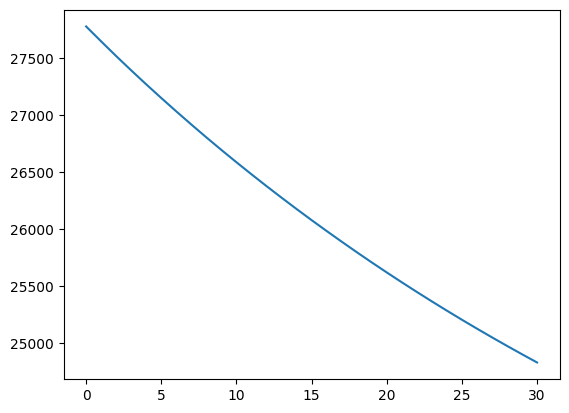

In [34]:
l = torch.tensor(loss['loss'], device = 'cpu')

plt.plot(l)

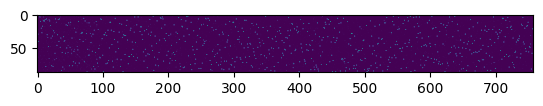

In [35]:
plt.imshow(G.cpu())

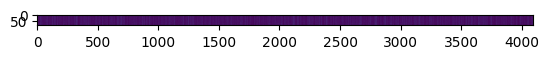

In [36]:
plt.imshow(L.cpu())

In [37]:
barysvm = train_svm(barycenter.cpu(), y_bari.cpu(), kernel='rbf', C=2.0)
model.fit_status_ == 0

[LibSVM].*
optimization finished, #iter = 259
obj = -141.912179, rho = -0.521542
nSV = 155, nBSV = 39
.*
optimization finished, #iter = 269
obj = -141.419461, rho = -0.510032
nSV = 155, nBSV = 35
.*
optimization finished, #iter = 293
obj = -146.280511, rho = -0.182963
nSV = 168, nBSV = 37
.*
optimization finished, #iter = 265
obj = -129.334471, rho = -0.499857
nSV = 148, nBSV = 27
.*
optimization finished, #iter = 290
obj = -143.931684, rho = -0.500097
nSV = 168, nBSV = 35
.*
optimization finished, #iter = 280
obj = -149.516094, rho = -0.067203
nSV = 173, nBSV = 80
.*
optimization finished, #iter = 267
obj = -126.620601, rho = -0.208347
nSV = 153, nBSV = 27
.*
optimization finished, #iter = 271
obj = -125.613935, rho = -0.324105
nSV = 146, nBSV = 24
.*
optimization finished, #iter = 259
obj = -147.883464, rho = -0.286059
nSV = 156, nBSV = 36
.*
optimization finished, #iter = 258
obj = -141.240991, rho = 0.041580
nSV = 141, nBSV = 51
.*
optimization finished, #iter = 267
obj = -141.6340

True

{'accuracy': 0.945910290237467, 'recall': array([0.89411765, 0.98571429, 0.95774648, 0.95180723, 0.97014925,
       0.92857143, 0.92134831, 0.94366197, 0.984375  , 0.94594595]), 'precision': array([0.98701299, 0.95833333, 0.95774648, 0.95180723, 0.94202899,
       0.91764706, 0.95348837, 0.89333333, 0.95454545, 0.94594595]), 'fscore': array([0.9382716 , 0.97183099, 0.95774648, 0.95180723, 0.95588235,
       0.92307692, 0.93714286, 0.91780822, 0.96923077, 0.94594595])}


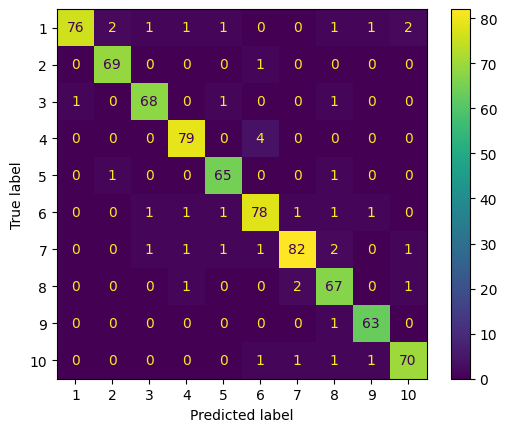

In [38]:
metrics, disp = test_svm(barysvm, barycenter.cpu(), y_bari.cpu())
disp.plot()
print(metrics)

In [49]:
mapped_source = barycentric_mapping(xs=X_trains[0],
                                    xt=barycenter,
                                    xnew=X_trains[0],
                                    coupling=G)
import ot.mapping
kernel = ot.mapping.kernel(X_trains[0], X_trains[0], method='gaussian', sigma=1e-3)
transported_source = np.dot(kernel.cpu(), L.cpu())

In [40]:
transported_source.shape

torch.Size([88, 4096])

{'accuracy': 0.13636363636363635, 'recall': array([0.        , 0.66666667, 0.        , 0.125     , 0.25      ,
       0.44444444, 0.        , 0.        , 0.        , 0.11111111]), 'precision': array([0.        , 0.25      , 0.        , 0.25      , 0.2       ,
       0.13333333, 0.        , 0.        , 0.        , 0.11111111]), 'fscore': array([0.        , 0.36363636, 0.        , 0.16666667, 0.22222222,
       0.20512821, 0.        , 0.        , 0.        , 0.11111111])}


/Users/balazsmorvay/anaconda3/envs/fmri_classifier/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


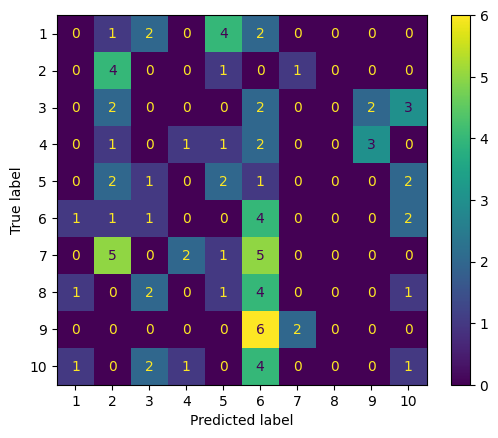

In [51]:
metrics, disp = test_svm(barysvm, transported_source, y_trains[0].cpu())
disp.plot()
print(metrics)

In [42]:
xs = X_trains[0].to(device)
xt = barycenter.to(device)
ys = y_trains[0].to(device)
yt = y_bari.to(device)
M = dist_classreg(xs, xt, ys, yt, device=device)

a = torch.tensor([1.0 / xs.shape[0]] * xs.shape[0], dtype=torch.float32, device=device)
b = torch.tensor([1.0 / xt.shape[0]] * xt.shape[0], dtype=torch.float32, device=device)

P = ot.sinkhorn(a=a, b=b, reg=5e-1, M=M, method='sinkhorn_log')

/Users/balazsmorvay/anaconda3/envs/fmri_classifier/lib/python3.11/site-packages/ot/bregman/_sinkhorn.py:748: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn("Sinkhorn did not converge. You might want to "


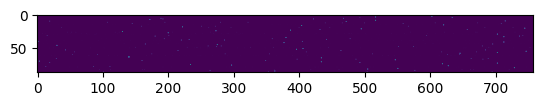

In [43]:
plt.imshow(P.cpu())

In [98]:
mapped_source_sinkhorn = barycentric_mapping(xs=X_trains[0],
                                    xt=barycenter,
                                    xnew=X_trains[0],
                                    coupling=P)
mapped_test_sinkhorn = barycentric_mapping(xs=X_trains[0],
                                    xt=barycenter,
                                    xnew=X_tests[0],
                                    coupling=P)

In [92]:
X_tests[0].shape, y_tests[0].shape, mapped_test_sinkhorn.shape

(torch.Size([207, 4096]), torch.Size([207]), torch.Size([88, 4096]))

{'accuracy': 0.9431818181818182, 'recall': array([1.        , 1.        , 1.        , 1.        , 1.        ,
       0.88888889, 1.        , 0.55555556, 1.        , 1.        ]), 'precision': array([0.9 , 1.  , 0.75, 1.  , 1.  , 1.  , 1.  , 1.  , 1.  , 0.9 ]), 'fscore': array([0.94736842, 1.        , 0.85714286, 1.        , 1.        ,
       0.94117647, 1.        , 0.71428571, 1.        , 0.94736842])}


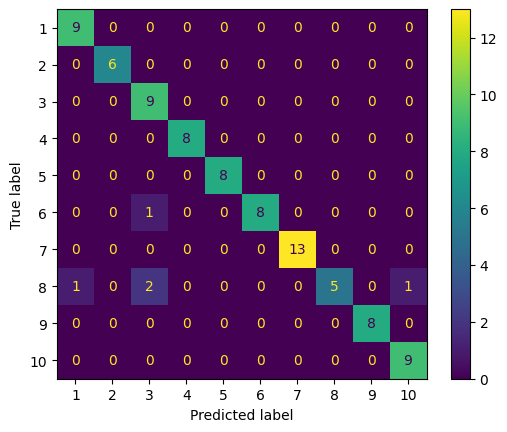

In [99]:
metrics, disp = test_svm(barysvm, mapped_source_sinkhorn.cpu(), y_trains[0].cpu())
disp.plot()
print(metrics)